 Import necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [ ]:
# Load the data
file_path=r'C:\Users\Veeresh\OneDrive\Documents\Desktop\gold\gld_price_data.csv'
gold = pd.read_csv(file_path)

In [ ]:
# Data overview
print(gold.shape)
print(gold.head())
print(gold.tail())
print(gold.info())
print(gold.describe())

(2290, 6)
       Date          SPX        GLD        USO     SLV   EUR/USD
0  1/2/2008  1447.160034  84.860001  78.470001  15.180  1.471692
1  1/3/2008  1447.160034  85.570000  78.370003  15.285  1.474491
2  1/4/2008  1411.630005  85.129997  77.309998  15.167  1.475492
3  1/7/2008  1416.180054  84.769997  75.500000  15.053  1.468299
4  1/8/2008  1390.189941  86.779999  76.059998  15.590  1.557099
           Date          SPX         GLD      USO      SLV   EUR/USD
2285   5/8/2018  2671.919922  124.589996  14.0600  15.5100  1.186789
2286   5/9/2018  2697.790039  124.330002  14.3700  15.5300  1.184722
2287  5/10/2018  2723.070068  125.180000  14.4100  15.7400  1.191753
2288  5/14/2018  2730.129883  124.489998  14.3800  15.5600  1.193118
2289  5/16/2018  2725.780029  122.543800  14.4058  15.4542  1.182033
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0  

In [ ]:
# information about the dataset
gold.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [ ]:
# Missing Values/Null Values Count
gold.isna().sum().sort_values(ascending=False)


Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [ ]:
# Missing Values/Null Values Count
gold.isna().sum().sort_values(ascending=False)

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [ ]:
# Convert Date to datetime
gold['Date'] = pd.to_datetime(gold['Date'])

In [ ]:
# Correlation matrix
coorelation = gold.corr()

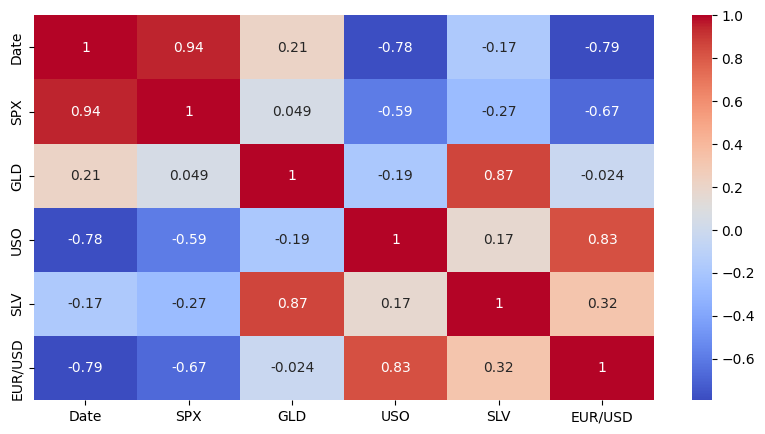

In [ ]:
# Heat map
plt.figure(figsize=(10, 5))
sns.heatmap(coorelation, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Correlation with GLD
corr_with_gld = coorelation['GLD'].drop('GLD')
print(corr_with_gld)

Date       0.209118
SPX        0.049345
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


In [ ]:
# Features and target variable
X = gold.drop(columns=['Date', 'GLD'], axis=1)
y = gold['GLD']
print(X.shape, y.shape)

(2290, 4) (2290,)


In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

In [ ]:
# Random Forest model
random_model = RandomForestRegressor()
random_model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
joblib.dump(random_model, 'randomforest.pkl')

['randomforest.pkl']

In [ ]:
# Predictions and evaluation for Random Forest
y_train_predicted_rf = random_model.predict(X_train)
y_test_predicted_rf = random_model.predict(X_test)

train_r2_rf = metrics.r2_score(y_train, y_train_predicted_rf)
test_r2_rf = metrics.r2_score(y_test, y_test_predicted_rf)

print(f"Random Forest Train R2 Score: {train_r2_rf}")
print(f"Random Forest Test R2 Score: {test_r2_rf}")

Random Forest Train R2 Score: 0.9980205437606718
Random Forest Test R2 Score: 0.9877831237584397


In [ ]:
## K-Nearest Neighbors (KNN) Model
knn_model = KNeighborsRegressor()
knn_model.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
joblib.dump(knn_model, 'knn.pkl')

['knn.pkl']

In [ ]:
# Predictions and evaluation for KNN
y_train_pred_knn = knn_model.predict(X_train)
y_test_pred_knn = knn_model.predict(X_test)

train_r2_knn = r2_score(y_train, y_train_pred_knn)
test_r2_knn = r2_score(y_test, y_test_pred_knn)

print(f"KNN Train R2 Score: {train_r2_knn}")
print(f"KNN Test R2 Score: {test_r2_knn}")

KNN Train R2 Score: 0.949284166722216
KNN Test R2 Score: 0.9178680837485367


In [ ]:
## Decision Tree Model
decision_tree_model = DecisionTreeRegressor(random_state=2)
decision_tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=2)

In [ ]:
joblib.dump(decision_tree_model, 'decisiontree.pkl')

['decisiontree.pkl']

In [ ]:
# Predictions and evaluation for Decision Tree
y_train_pred_dt = decision_tree_model.predict(X_train)
y_test_pred_dt = decision_tree_model.predict(X_test)

train_r2_dt = r2_score(y_train, y_train_pred_dt)
test_r2_dt = r2_score(y_test, y_test_pred_dt)

print(f"Decision Tree Train R2 Score: {train_r2_dt}")
print(f"Decision Tree Test R2 Score: {test_r2_dt}")

Decision Tree Train R2 Score: 1.0
Decision Tree Test R2 Score: 0.973990569473708


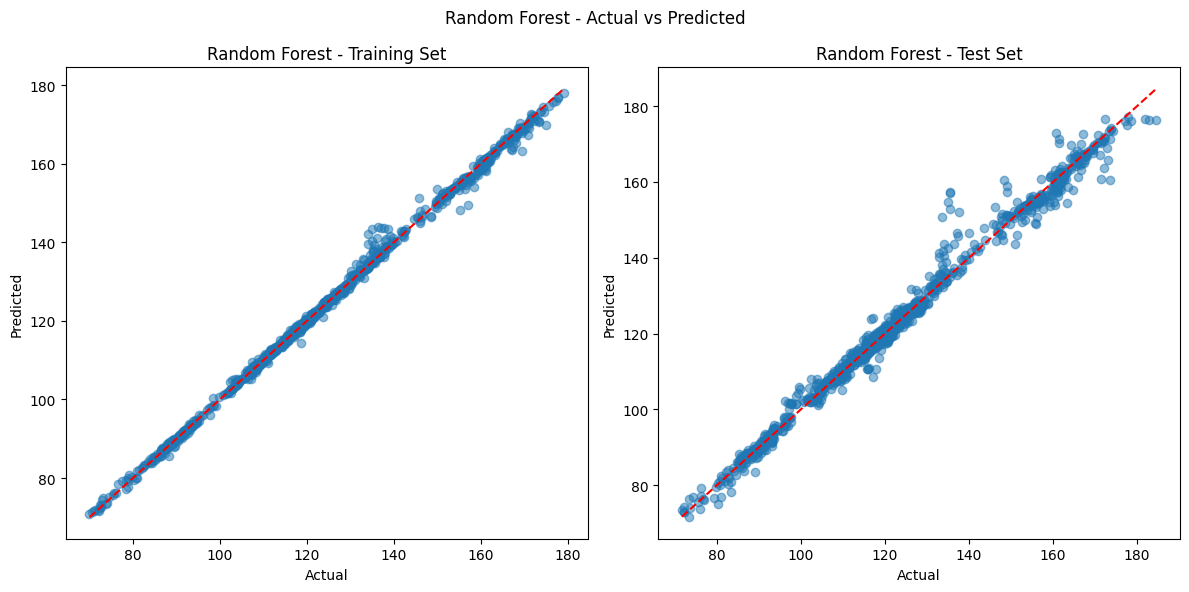

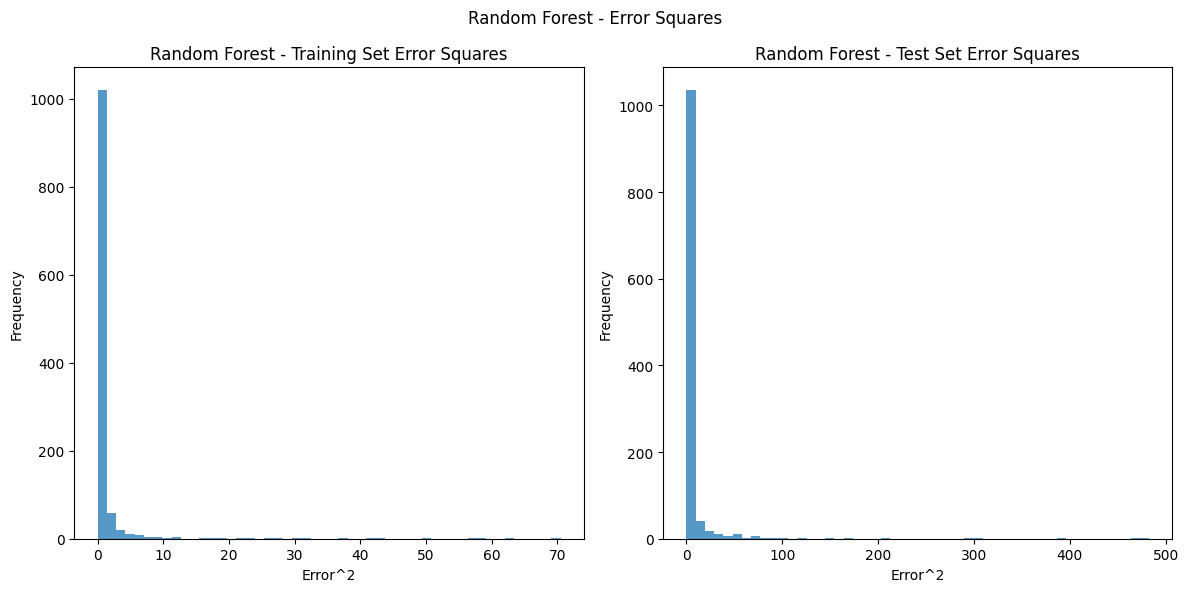

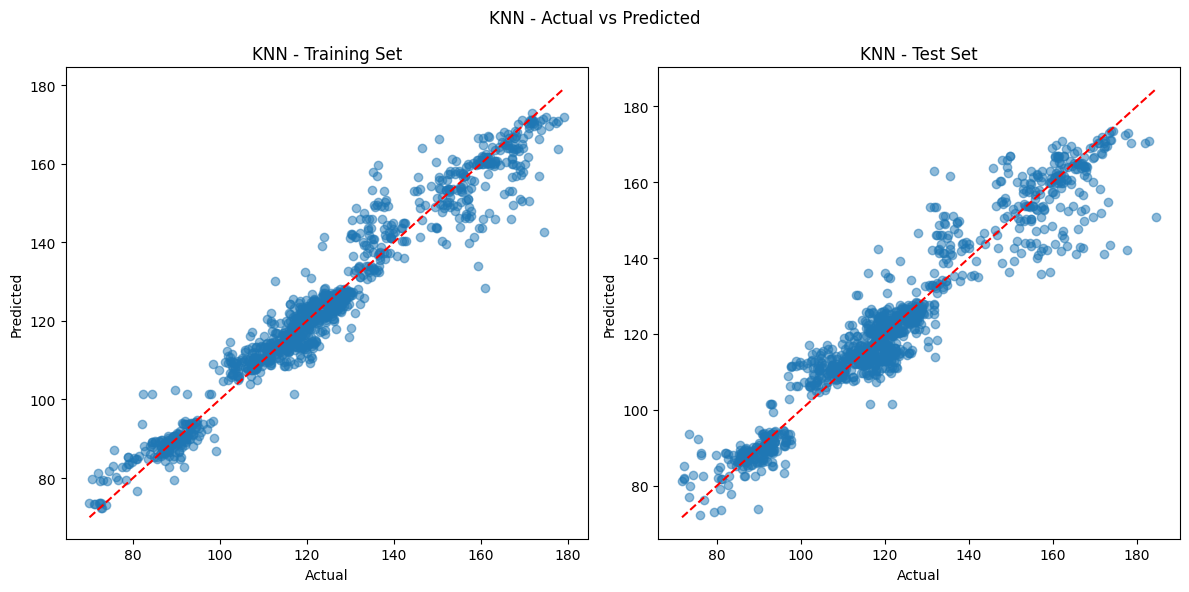

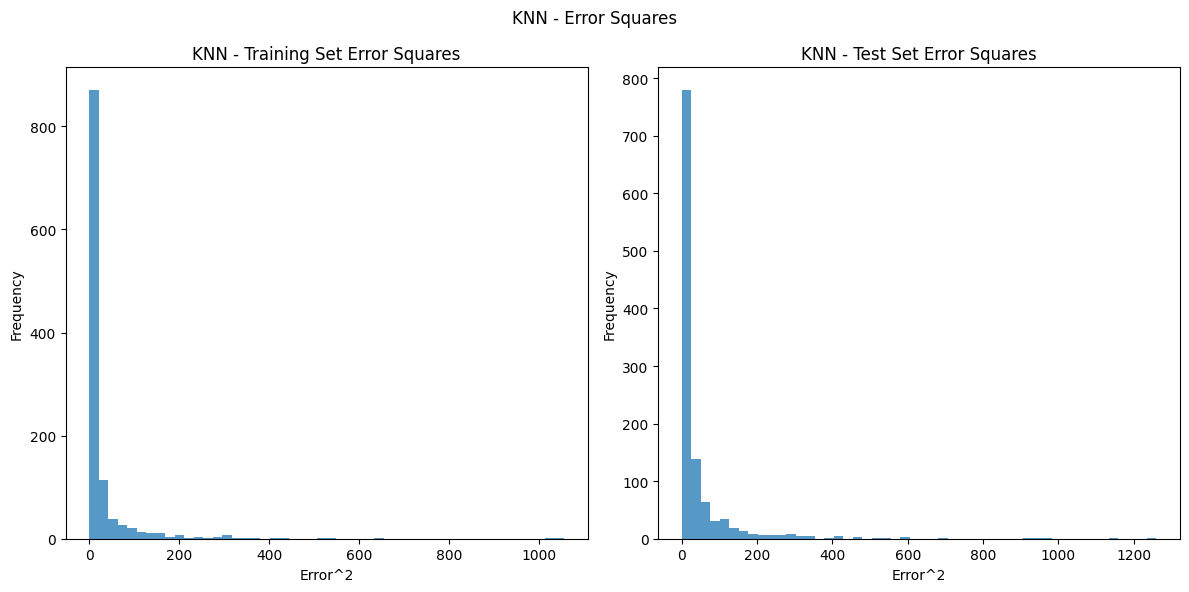

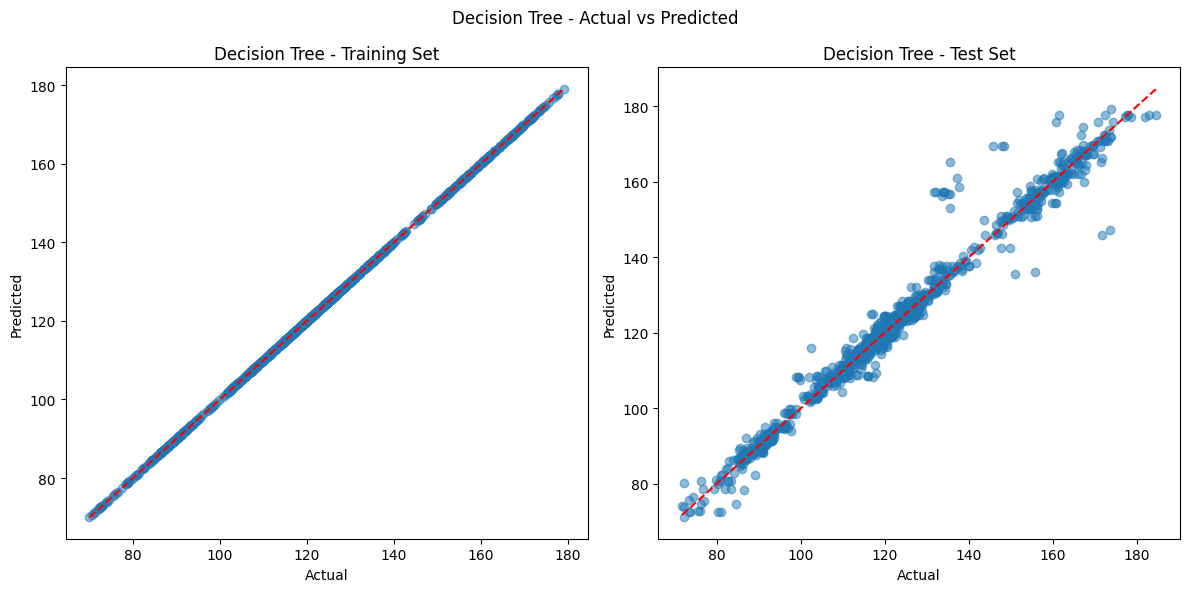

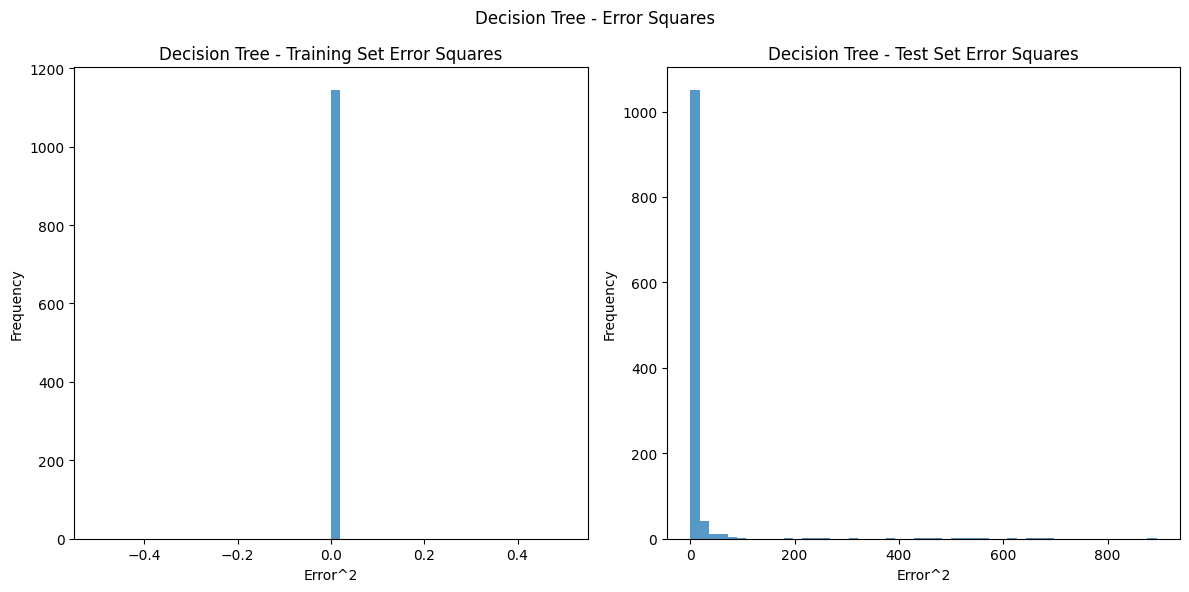

In [ ]:
# Plotting Actual vs Predicted and Error Squares for each model
models = {
    'Random Forest': (y_train_predicted_rf, y_test_predicted_rf),
    'KNN': (y_train_pred_knn, y_test_pred_knn),
    'Decision Tree': (y_train_pred_dt, y_test_pred_dt)
}

for model_name, (y_train_pred, y_test_pred) in models.items():
    plt.figure(figsize=(12, 6))

    # Training set
    plt.subplot(1, 2, 1)
    plt.scatter(y_train, y_train_pred, alpha=0.5)
    plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{model_name} - Training Set')

    # Test set
    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{model_name} - Test Set')

    plt.suptitle(f'{model_name} - Actual vs Predicted')
    plt.tight_layout()
    plt.show()

    # Error Squares
    plt.figure(figsize=(12, 6))

    # Training set errors
    plt.subplot(1, 2, 1)
    train_errors = (y_train - y_train_pred) ** 2
    plt.hist(train_errors, bins=50, alpha=0.75)
    plt.xlabel('Error^2')
    plt.ylabel('Frequency')
    plt.title(f'{model_name} - Training Set Error Squares')

    # Test set errors
    plt.subplot(1, 2, 2)
    test_errors = (y_test - y_test_pred) ** 2
    plt.hist(test_errors, bins=50, alpha=0.75)
    plt.xlabel('Error^2')
    plt.ylabel('Frequency')
    plt.title(f'{model_name} - Test Set Error Squares')

    plt.suptitle(f'{model_name} - Error Squares')
    plt.tight_layout()
    plt.show()

In [ ]:
print(X_train.shape[0],X_test.shape[0])

1145 1145


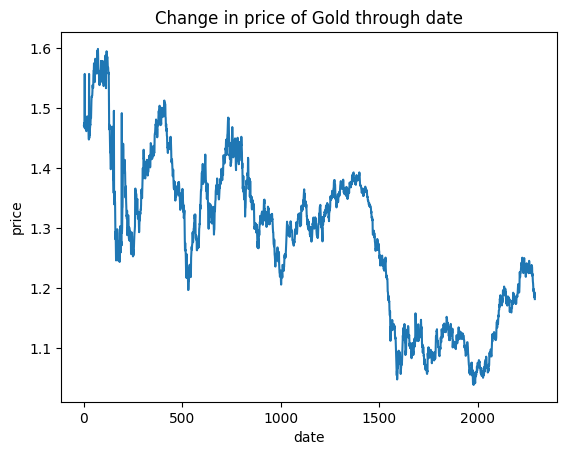

In [ ]:
# Check if 'EUR/USD' column exists
if 'EUR/USD' in gold.columns:
    # plot price of gold for each increasing day
    gold["EUR/USD"].plot()
    plt.title("Change in price of Gold through date")
    plt.xlabel("date")
    plt.ylabel("price")
    plt.show()
else:
    print("Column 'EUR/USD' not found in the DataFrame.")
    # If not found, inspect the available columns
    print("Available columns:", gold.columns)

In [ ]:
# Assuming you have your data in a DataFrame called 'dataset'
# and you want to split it into training and testing sets

from sklearn.model_selection import train_test_split

# Print available columns to verify the correct column name
print(gold.columns)

# Split the data into features (X) and target (y)
# Replace 'Gold' with the actual name of your target column from the printed list
X = gold.drop('GLD', axis=1)  # Replace 'Gold' with 'GLD'
y = gold['GLD']  # Replace 'Gold' with 'GLD'

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Index(['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')


In [ ]:
# Calculate skewness for numerical columns only
numerical_dataset = gold.select_dtypes(include=['number'])
print(numerical_dataset.skew(axis=0, skipna=True))

SPX        0.300362
GLD        0.334138
USO        1.699331
SLV        1.153641
EUR/USD   -0.005292
dtype: float64


In [ ]:
# Check if 'USO' column exists before applying transformation
if 'USO' in gold.columns:
    # apply square root transformation
    # on the skewed dataset
    gold["USO"] = gold["USO"].apply(lambda x: np.sqrt(x))
else:
    print("Column 'USO' not found in the DataFrame.")

In [ ]:
fig = plt.figure(figsize=(8, 8))  # Adjust figure size for more subplots
# Check if 'Date' column exists before dropping
if 'Date' in gold.columns:
    temp = gold.drop("Date", axis=1).columns.tolist()
else:
    temp = gold.columns.tolist()  # Use all columns if 'Date' is not present

# Calculate the number of rows and columns for subplots
num_cols = 3  # Adjust as needed
num_rows = (len(temp) + num_cols - 1) // num_cols

<Figure size 800x800 with 0 Axes>

In [ ]:
%pip install plotly_express
import plotly.express as px
import pandas as pd

# Assuming you have calculated these accuracies previously
knn_acc = 0.85
dtc_acc = 0.92
rfc_acc = 0.95


models = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree Regression', 'Random Forest Regression'],
    'Score': [knn_acc, dtc_acc, rfc_acc]
})

models.sort_values(by='Score', ascending=False)

px.bar(data_frame=models, x='Score', y='Model', color='Score')


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: plotly_express in c:\users\veeresh\appdata\local\programs\python\python312\lib\site-packages (0.4.1)



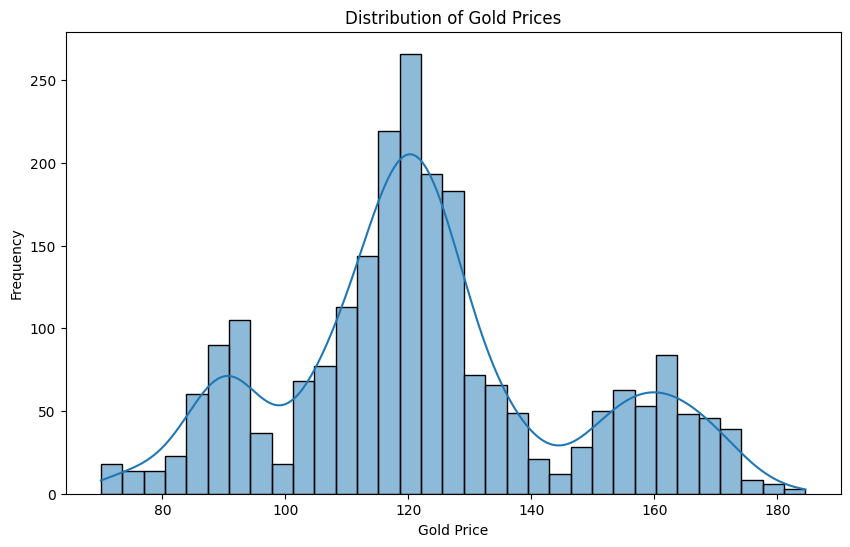

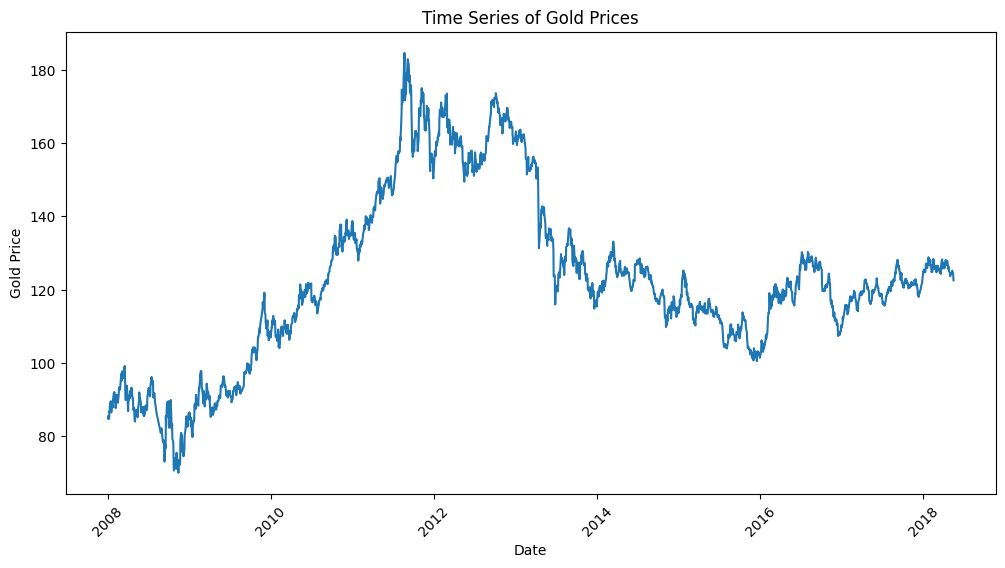

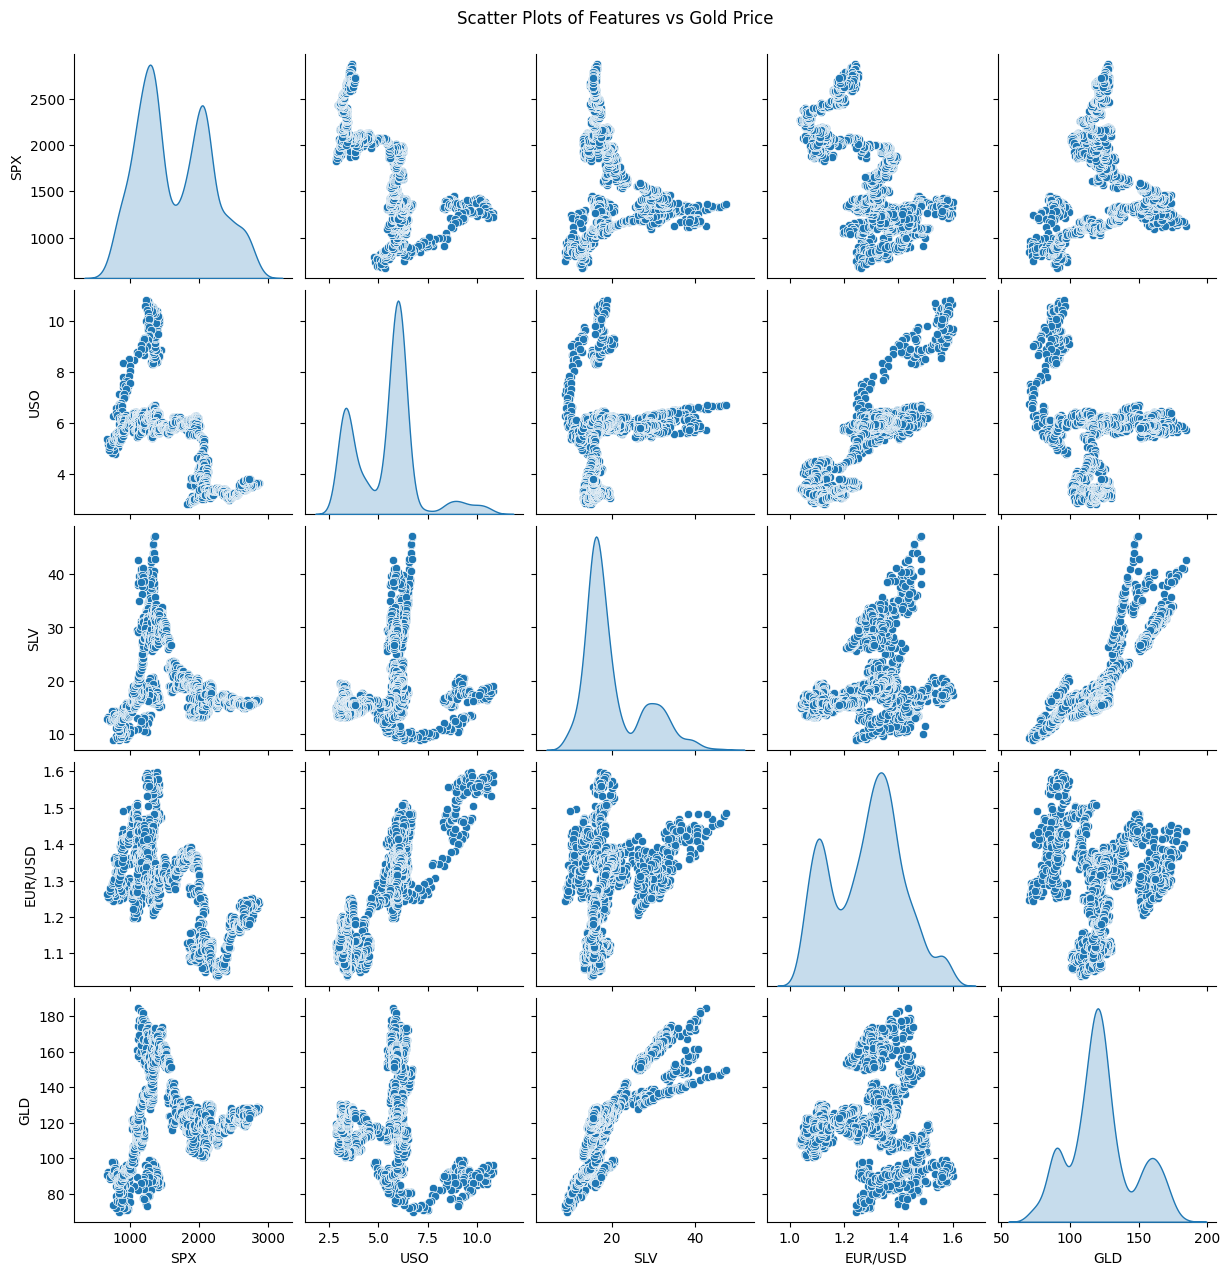

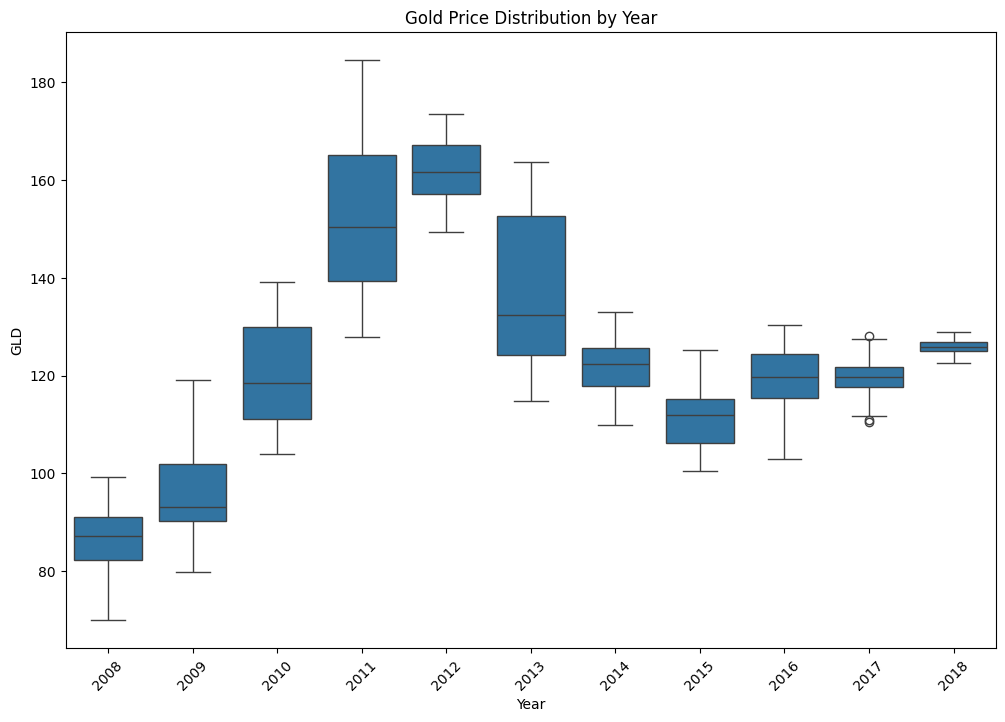

In [ ]:
# prompt: graphs

import pandas as pd
import matplotlib.pyplot as plt
# Assuming 'gold' DataFrame is already loaded and processed as in the preceding code

# 1. Distribution of Gold Prices
plt.figure(figsize=(10, 6))
sns.histplot(gold['GLD'], kde=True)
plt.title('Distribution of Gold Prices')
plt.xlabel('Gold Price')
plt.ylabel('Frequency')
plt.show()

# 2. Time Series of Gold Prices
plt.figure(figsize=(12, 6))
plt.plot(gold['Date'], gold['GLD'])
plt.title('Time Series of Gold Prices')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.xticks(rotation=45)
plt.show()

# 3. Scatter Plots for Feature Relationships
sns.pairplot(gold[['SPX', 'USO', 'SLV', 'EUR/USD', 'GLD']], diag_kind='kde')
plt.suptitle('Scatter Plots of Features vs Gold Price', y=1.02)
plt.show()

# 4. Box Plots for Feature Distributions by Year (if 'Date' is available)
if 'Date' in gold.columns:
    gold['Year'] = gold['Date'].dt.year
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='Year', y='GLD', data=gold)
    plt.title('Gold Price Distribution by Year')
    plt.xticks(rotation=45)
    plt.show()

# 5. Interactive Plotly Chart for Model Comparison
import plotly.express as px

models = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Random Forest'],
    'Train R2': [train_r2_knn, train_r2_dt, train_r2_rf],
    'Test R2': [test_r2_knn, test_r2_dt, test_r2_rf]
})

fig = px.bar(models, x='Model', y=['Train R2', 'Test R2'], barmode='group',
             title='Model Comparison - Train vs Test R2 Scores')
fig.show()


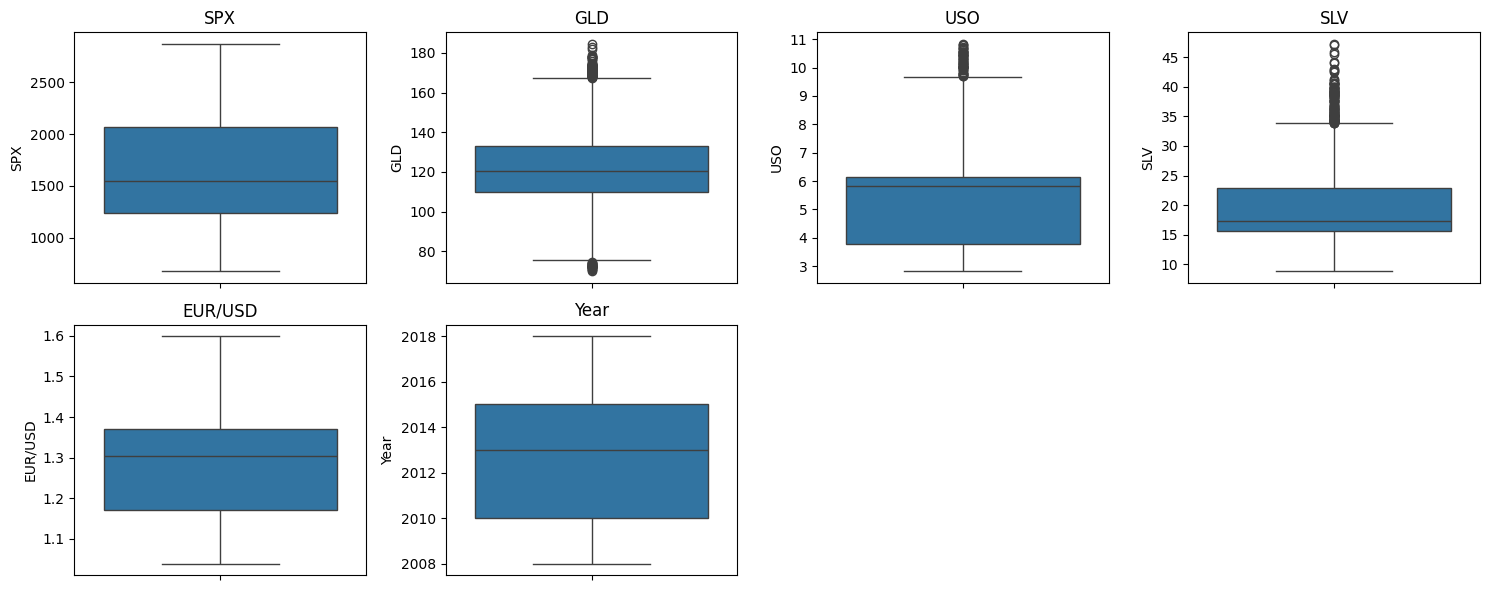

In [ ]:
# outliers datapoint graph

import matplotlib.pyplot as plt
# Box plots to visualize outliers
plt.figure(figsize=(15, 6))
for i, col in enumerate(gold.columns[1:], 1):  # Start from second column (index 1)
    plt.subplot(2, 4, i)
    sns.boxplot(y=gold[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [ ]:
# prompt: outliers handling

# Calculate IQR for each numerical column
Q1 = numerical_dataset.quantile(0.25)
Q3 = numerical_dataset.quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = ((numerical_dataset < lower_bound) | (numerical_dataset > upper_bound)).sum()
print(outliers)

# Handle outliers (choose one or combine methods)

# 1. Capping (Winsorization)
# Cap outliers at the upper and lower bounds
capped_dataset = numerical_dataset.clip(lower_bound, upper_bound, axis=1)

# 2. Removal
# Remove rows with outliers
# Be cautious with this, as it can lead to data loss
filtered_dataset = numerical_dataset[~((numerical_dataset < lower_bound) | (numerical_dataset > upper_bound)).any(axis=1)]

# 3. Transformation
# Apply transformations like log or square root to reduce the impact of outliers
# This might be suitable for certain skewed distributions

# 4. Imputation
# Replace outliers with more reasonable values, such as the mean or median
# This can be useful if you don't want to lose data points

# Choose the most appropriate method based on your data and analysis goals


SPX          0
GLD        115
USO        134
SLV        117
EUR/USD      0
dtype: int64


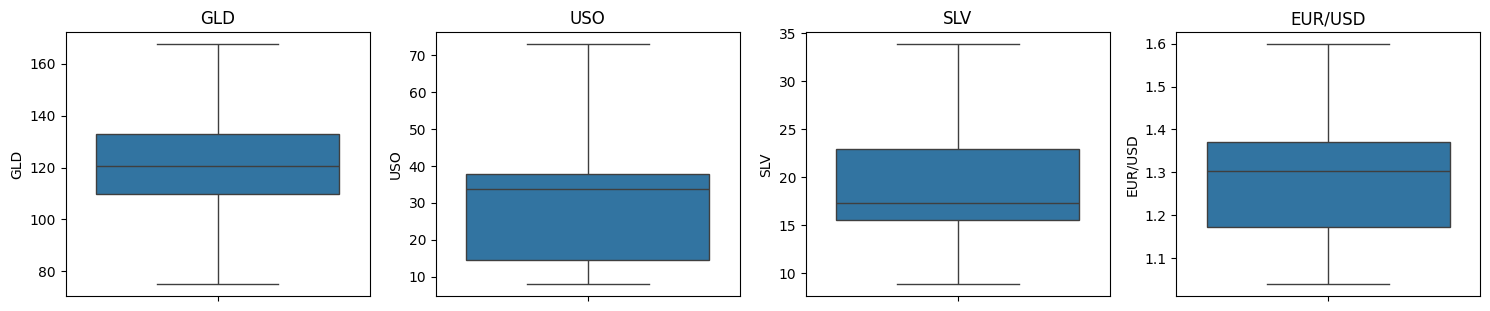

In [ ]:
# prompt: after outlierse handled graph

import matplotlib.pyplot as plt
# Assuming you have handled outliers using one of the methods described in the previous response
# and the resulting DataFrame is named 'processed_gold'

# If you haven't processed the outliers yet, do it here. For example, using capping:
processed_gold = numerical_dataset.clip(lower_bound, upper_bound, axis=1)

# Box plots to visualize the effect of outlier handling
plt.figure(figsize=(15, 6))
for i, col in enumerate(processed_gold.columns[1:], 1):  # Start from second column (index 1)
    plt.subplot(2, 4, i)
    sns.boxplot(y=processed_gold[col])
    plt.title(col)
plt.tight_layout()
plt.show()